<h1>Preparacion del DataSet utilizando OpenCV para recortar los rostros</h1>

<h3>Primero debemos instalarlo en el enviroment</h3> <br/>
pip install opencv-python matplotlib tqdm


In [1]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

Configuramos las rutas

In [29]:
# Carpeta donde están tus frames completos
SET_DIR = "Daniel" 
RAW_DIR = Path(r"D:\\Aplicaciones multiplataforma\\002 - RelojChecador IA\\Training\\VideosPostProcesados\\"+SET_DIR+"Set")

# Carpeta donde se guardarán los rostros recortados
OUT_TRAIN_DIR = Path(r"D:\\Aplicaciones multiplataforma\\002 - RelojChecador IA\\Training\\DataSet\\Train\\"+SET_DIR+"Set")
OUT_VAL_DIR = Path(r"D:\\Aplicaciones multiplataforma\\002 - RelojChecador IA\\Training\\DataSet\\Validation\\"+SET_DIR+"Set")

OUT_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
OUT_VAL_DIR.mkdir(parents=True, exist_ok=True)

# Hasta qué frame será entrenamiento
TRAIN_LAST_FRAME = 200

# Tamaño final para la CNN
IMG_SIZE = 128

# Margen extra alrededor del rostro
MARGIN = 0.25

Cargamos el detector facial

In [30]:
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_detector = cv2.CascadeClassifier(cascade_path)

if face_detector.empty():
    raise Exception("No se pudo cargar el detector Haar Cascade.")

Función auxiliar para recortar rostro

In [31]:
def crop_largest_face(image_path, img_size=128, margin=0.25):
    image = cv2.imread(str(image_path))

    if image is None:
        return None, "imagen_no_leida"

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        return None, "sin_rostro"

    # Elegir el rostro más grande
    x, y, w, h = max(faces, key=lambda face: face[2] * face[3])

    # Agregar margen
    margin_x = int(w * margin)
    margin_y = int(h * margin)

    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(image.shape[1], x + w + margin_x)
    y2 = min(image.shape[0], y + h + margin_y)

    face_crop = image[y1:y2, x1:x2]

    if face_crop.size == 0:
        return None, "recorte_vacio"

    face_resized = cv2.resize(face_crop, (img_size, img_size))

    return face_resized, "ok"

Prueba unitaria para una imagen

Estado: ok


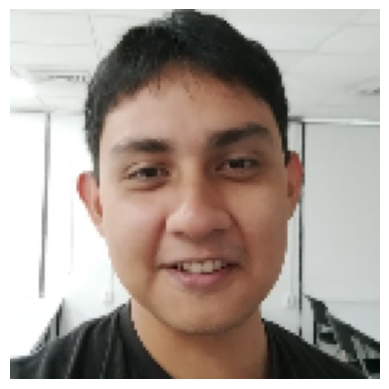

In [32]:
test_image = RAW_DIR / "frame_0001.jpg"

face, status = crop_largest_face(test_image, IMG_SIZE, MARGIN)

print("Estado:", status)

if face is not None:
    face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    plt.imshow(face_rgb)
    plt.axis("off")
    plt.show()

Procesador de frames

In [33]:
def get_frame_number(path):
    """
    Espera nombres tipo:
    frame_0001.jpg
    frame_0175.jpg
    """
    stem = path.stem  # frame_0001
    number_part = stem.split("_")[-1]
    return int(number_part)

In [34]:
image_files = sorted(
    list(RAW_DIR.glob("*.jpg")) + 
    list(RAW_DIR.glob("*.jpeg")) + 
    list(RAW_DIR.glob("*.png"))
)

print("Imágenes encontradas:", len(image_files))

Imágenes encontradas: 277


In [35]:
stats = {
    "ok_train": 0,
    "ok_validation": 0,
    "sin_rostro": 0,
    "imagen_no_leida": 0,
    "recorte_vacio": 0,
    "error": 0
}

failed_images = []

for image_path in tqdm(image_files):
    try:
        frame_number = get_frame_number(image_path)

        face, status = crop_largest_face(image_path, IMG_SIZE, MARGIN)

        if status != "ok":
            stats[status] = stats.get(status, 0) + 1
            failed_images.append((image_path.name, status))
            continue

        if frame_number <= TRAIN_LAST_FRAME:
            output_path = OUT_TRAIN_DIR / f"{SET_DIR}_{frame_number:04d}.jpg"
            stats["ok_train"] += 1
        else:
            output_path = OUT_VAL_DIR / f"{SET_DIR}_{frame_number:04d}.jpg"
            stats["ok_validation"] += 1

        cv2.imwrite(str(output_path), face)

    except Exception as e:
        stats["error"] += 1
        failed_images.append((image_path.name, str(e)))

print(stats)
print("Fallidas:", len(failed_images))

100%|██████████| 277/277 [00:25<00:00, 10.91it/s]

{'ok_train': 150, 'ok_validation': 67, 'sin_rostro': 60, 'imagen_no_leida': 0, 'recorte_vacio': 0, 'error': 0}
Fallidas: 60


Mostramos algunas imagenes recortadas 

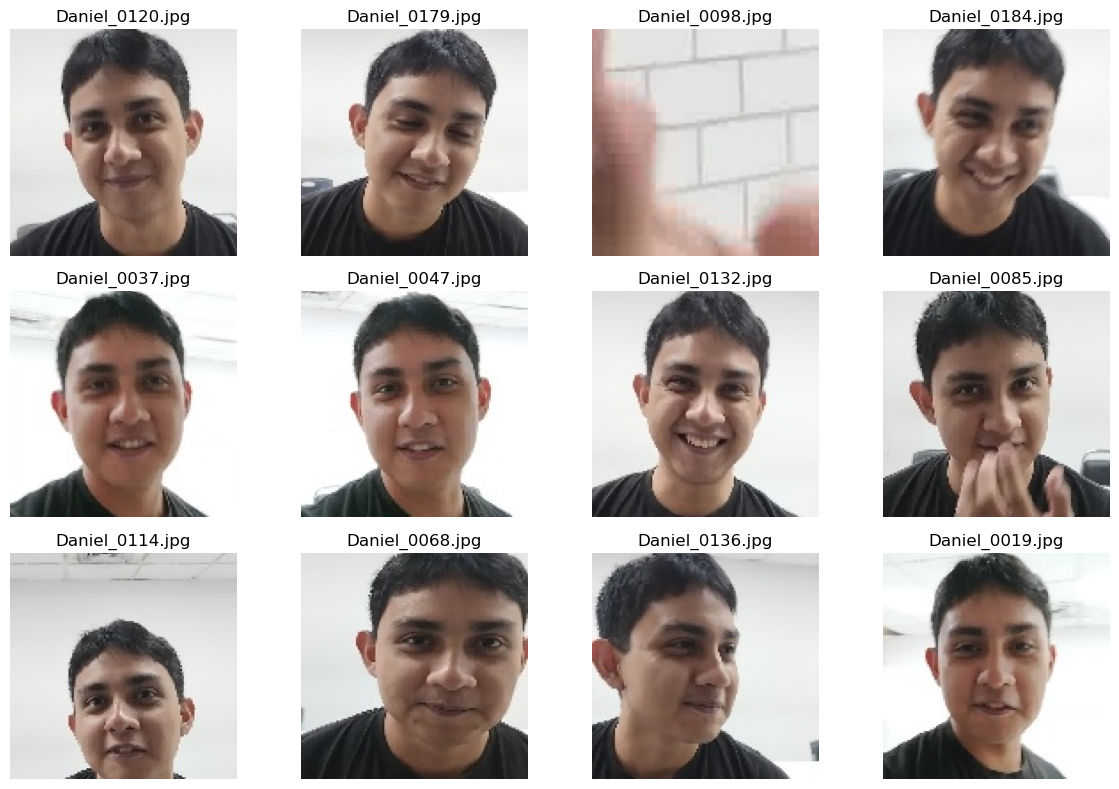

In [36]:
import random

sample_files = random.sample(list(OUT_TRAIN_DIR.glob("*.jpg")), min(12, len(list(OUT_TRAIN_DIR.glob("*.jpg")))))

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_files):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
asdasd  

NameError: name 'asdasd' is not defined

<h1>Dataset de intrusos

In [ ]:
from sklearn.datasets import fetch_lfw_people
import numpy as np

lfw = fetch_lfw_people(color=True, resize=1.0)
images = lfw.images

print("Shape:", images.shape)
print("Tipo:", images.dtype)
print("Min:", images.min())
print("Max:", images.max())

In [ ]:
import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(images)), 12)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):
    img = images[idx]

    # Para mostrar correctamente
    if img.max() > 1:
        img_show = img / 255.0
    else:
        img_show = img

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_show)
    plt.title(f"Index {idx}")
    plt.axis("off")

plt.show()

In [ ]:
from sklearn.datasets import fetch_lfw_people
from pathlib import Path
from PIL import Image
import numpy as np
import random

TRAIN_INTRUSO = Path(r"D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\DataSet\Train\Intruso")
VAL_INTRUSO = Path(r"D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\DataSet\Validation\Intruso")

TRAIN_INTRUSO.mkdir(parents=True, exist_ok=True)
VAL_INTRUSO.mkdir(parents=True, exist_ok=True)

lfw = fetch_lfw_people(color=True, resize=1.0)
images = lfw.images

print("Total imágenes:", len(images))
print("Min:", images.min())
print("Max:", images.max())
print("Tipo:", images.dtype)

indices = list(range(len(images)))
random.shuffle(indices)

num_train = 120
num_val = 40

train_indices = indices[:num_train]
val_indices = indices[num_train:num_train + num_val]

def preparar_imagen(img):
    # Si viene en rango 0-1, convertir a 0-255
    if img.max() <= 1.0:
        img = img * 255.0

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def save_images(selected_indices, output_dir, prefix):
    for i, idx in enumerate(selected_indices, start=1):
        img = images[idx]
        img = preparar_imagen(img)

        pil_img = Image.fromarray(img)
        pil_img = pil_img.resize((224, 224))

        output_path = output_dir / f"{prefix}_{i:04d}.jpg"
        pil_img.save(output_path)

save_images(train_indices, TRAIN_INTRUSO, "Intruso")
save_images(val_indices, VAL_INTRUSO, "Intruso")

print("Intrusos generados correctamente")
print("Train:", len(list(TRAIN_INTRUSO.glob('*.jpg'))))
print("Validation:", len(list(VAL_INTRUSO.glob('*.jpg'))))